In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [ ]:
df =pd.read_csv('Bank Churn_Modelling.csv')
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
#finding missing values
df.isnull().sum()


,0
RowNumber,0
CustomerId,0
Surname,0
CreditScore,0
Geography,0
Gender,0
Age,0
Tenure,0
Balance,0
NumOfProducts,0


In [ ]:
#Remove duplicates.
df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [ ]:
df.describe()

,RowNumber,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,10000.00000,1.000000e+04,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000,10000.000000,10000.000000,10000.000000
mean,5000.50000,1.569094e+07,650.528800,38.921800,5.012800,76485.889288,1.530200,0.70550,0.515100,100090.239881,0.203700
std,2886.89568,7.193619e+04,96.653299,10.487806,2.892174,62397.405202,0.581654,0.45584,0.499797,57510.492818,0.402769
min,1.00000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.00000,0.000000,11.580000,0.000000
25%,2500.75000,1.562853e+07,584.000000,32.000000,3.000000,0.000000,1.000000,0.00000,0.000000,51002.110000,0.000000
50%,5000.50000,1.569074e+07,652.000000,37.000000,5.000000,97198.540000,1.000000,1.00000,1.000000,100193.915000,0.000000
75%,7500.25000,1.575323e+07,718.000000,44.000000,7.000000,127644.240000,2.000000,1.00000,1.000000,149388.247500,0.000000
max,10000.00000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.00000,1.000000,199992.480000,1.000000


In [ ]:
df.count()

,0
RowNumber,10000
CustomerId,10000
Surname,10000
CreditScore,10000
Geography,10000
Gender,10000
Age,10000
Tenure,10000
Balance,10000
NumOfProducts,10000


In [ ]:
#fixing column name
df.columns = df.columns.str.capitalize()
df.head()

,Rownumber,Customerid,Surname,Creditscore,Geography,Gender,Age,Tenure,Balance,Numofproducts,Hascrcard,Isactivemember,Estimatedsalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [ ]:
#Feature Engineering
df['Balance'].unique()
df['Balance category'] = pd.cut(
    df['Balance'],
    bins = [0,50000,100000,200000],
    labels=['Low','Medium','High']
    )

df['Credit_group'] = pd.cut(
    df['Creditscore'],
    bins = [300,600,750,1000],
    labels=['Poor','Fair','Good']
)
df['Age_group'] = pd.cut(
    df['Age'],
    bins =[18,30,40,50,60,70,100],
    labels=['18-30','31-40','41-50','51-60','61-70','71-100']
)



In [ ]:

df.head()

,Rownumber,Customerid,Surname,Creditscore,Geography,Gender,Age,Tenure,Balance,Numofproducts,Hascrcard,Isactivemember,Estimatedsalary,Exited,Balance category,Credit_group,Age_group
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,NaN,Fair,41-50
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Medium,Fair,41-50
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,High,Poor,41-50
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,NaN,Fair,31-40
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,High,Good,41-50


In [ ]:

print(df['Creditscore'].min())
print(df['Creditscore'].max())

350
850


In [ ]:
#Which age group leaves most?
exited_by_age = df[df['Exited'] == 1]
exited_by_age['Age_group'].value_counts()

,count
Age_group,
41-50,788
31-40,538
51-60,448
18-30,146
61-70,104
71-100,11


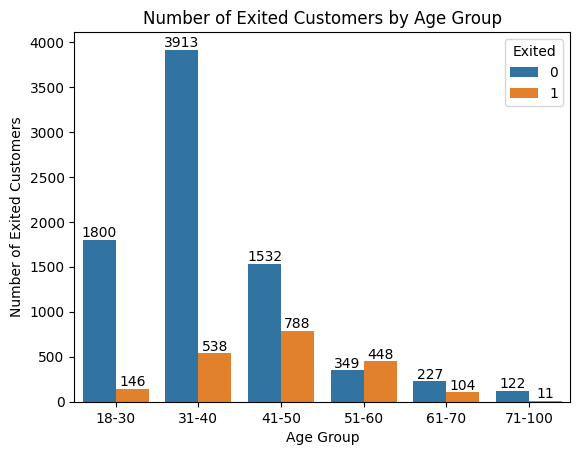

In [ ]:
ax = sns.countplot(data=df,x='Age_group',hue = 'Exited')
for i in ax.containers:
  ax.bar_label(i)
plt.xlabel('Age Group')
plt.ylabel('Number of Exited Customers')
plt.title('Number of Exited Customers by Age Group')
plt.show()

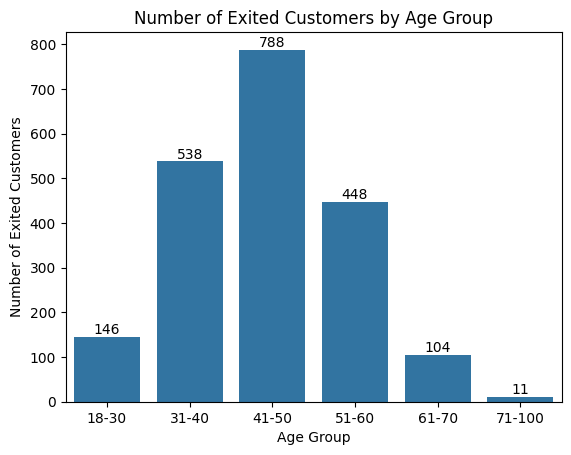

In [ ]:
ax = sns.countplot(data=exited_by_age,x='Age_group')
for i in ax.containers:
  ax.bar_label(i)
plt.xlabel('Age Group')
plt.ylabel('Number of Exited Customers')
plt.title('Number of Exited Customers by Age Group')
plt.show()


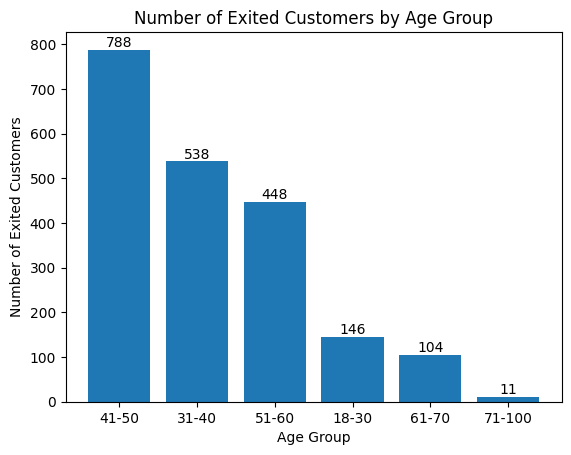

In [ ]:
ax = plt.bar(exited_by_age['Age_group'].value_counts().index,exited_by_age['Age_group'].value_counts().values)
plt.bar_label(ax)
plt.xlabel('Age Group')
plt.ylabel('Number of Exited Customers')
plt.title('Number of Exited Customers by Age Group')
plt.show()

In [ ]:
df.head()

,Rownumber,Customerid,Surname,Creditscore,Geography,Gender,Age,Tenure,Balance,Numofproducts,Hascrcard,Isactivemember,Estimatedsalary,Exited,Balance category,Credit_group,Age_group
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,NaN,Fair,41-50
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Medium,Fair,41-50
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,High,Poor,41-50
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,NaN,Fair,31-40
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,High,Good,41-50


In [ ]:
glmc= df.groupby('Geography')['Exited'].value_counts()
glmc

Geography  Exited
France     0         4204
           1          810
Germany    0         1695
           1          814
Spain      0         2064
           1          413
Name: count, dtype: int64

In [ ]:
df[df['Exited'] == 1]['Geography'].value_counts()


,count
Geography,
Germany,814
France,810
Spain,413


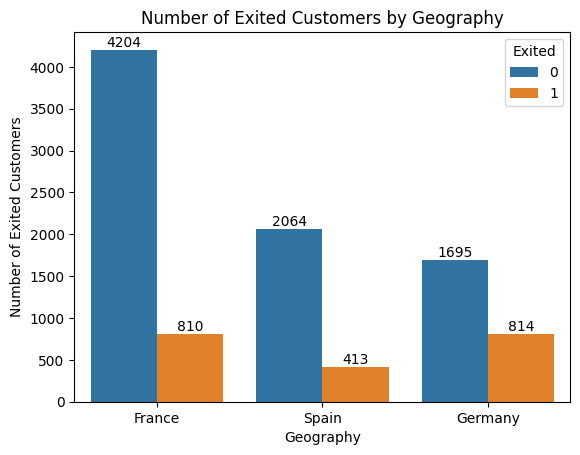

In [ ]:
#Which geography loses most customers?
ax = sns.countplot(data=df,x='Geography',hue = 'Exited')
for i in ax.containers:
  ax.bar_label(i)
plt.xlabel('Geography')
plt.ylabel('Number of Exited Customers')
plt.title('Number of Exited Customers by Geography')
plt.show()

In [ ]:
#Which balance range has highest churn?
df[df['Exited']==1]['Balance category'].value_counts()

,count
Balance category,
High,1192
Medium,300
Low,26


In [ ]:
bal_r_h_ch = df.groupby('Balance category')['Exited'].value_counts()
bal_r_h_ch

Balance category  Exited
Low               0           49
                  1           26
Medium            0         1209
                  1          300
High              0         3573
                  1         1192
Name: count, dtype: int64

In [ ]:
#Business Questions
#1 How many customers?
#2 What is churn rate?
#3 Which age group leaves most?
#4 Which country loses most customers?
#5 Which balance category churns most?


In [ ]:
#1 How many customers?
df['Customerid'].count()

np.int64(10000)

In [ ]:
#2 What is churn rate?
churn_rate = df['Exited'].value_counts(normalize= True)[1]# normalize True convert the raw frequency count into proportions(percentages).the resulting proportions will always sum upto 1
churn_rate

np.float64(0.2037)

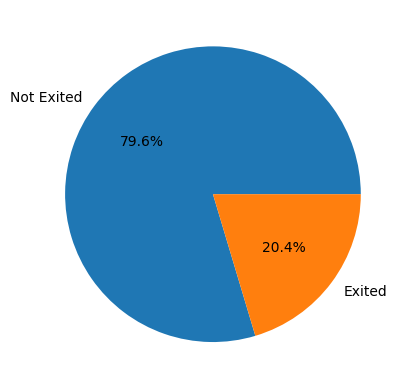

In [ ]:
plt.pie(df['Exited'].value_counts(),labels=['Not Exited','Exited'],autopct='%1.1f%%')
plt.show()

In [ ]:
#3 Which age group leaves most?
df[df['Exited'] == 1]['Age_group'].value_counts()

,count
Age_group,
41-50,788
31-40,538
51-60,448
18-30,146
61-70,104
71-100,11


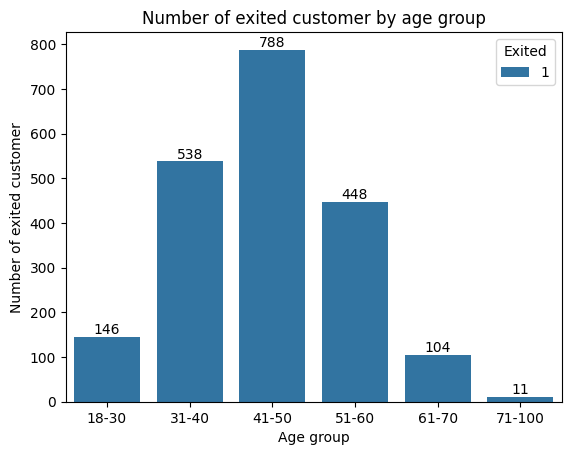

In [ ]:
ax = sns.countplot(data =exited_by_age,x = 'Age_group',hue ='Exited')
for i in ax.containers:
  ax.bar_label(i)
plt.xlabel('Age group')
plt.ylabel('Number of exited customer')
plt.title('Number of exited customer by age group')
plt.show()

In [ ]:
#4 Which country loses most customers in count?
df[df['Exited'] == 1]['Geography'].value_counts()

,count
Geography,
Germany,814
France,810
Spain,413


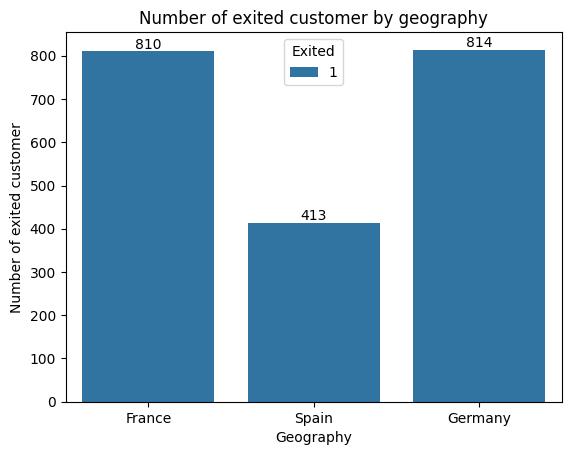

In [ ]:
ax = sns.countplot(data = exited_by_age,x = 'Geography',hue = 'Exited')
for i in ax.containers:
  ax.bar_label(i)
plt.xlabel('Geography')
plt.ylabel('Number of exited customer')
plt.title('Number of exited customer by geography')
plt.show()

In [ ]:
#which country has highest churn rate?
churn_rate_by_country = df.groupby('Geography')['Exited'].mean()*100
churn_rate_by_country

,Exited
Geography,
France,16.154767
Germany,32.443204
Spain,16.673395


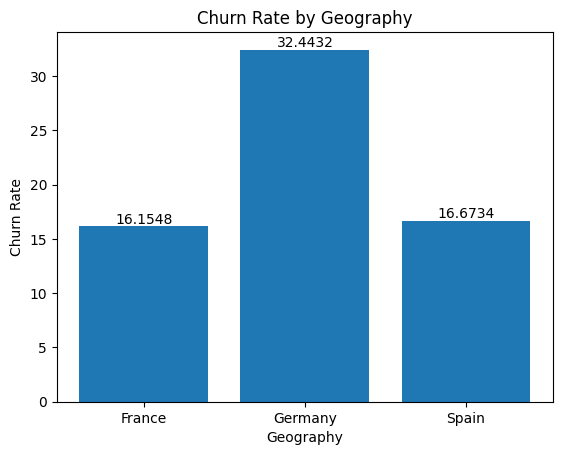

In [ ]:
ax = plt.bar(churn_rate_by_country.index,churn_rate_by_country.values )
plt.bar_label(ax)
plt.xlabel('Geography')
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Geography')
plt.show()

In [ ]:

#5 Which balance category churns count most?
df[df['Exited'] ==1]['Balance category'].value_counts()

,count
Balance category,
High,1192
Medium,300
Low,26


<function matplotlib.pyplot.show(close=None, block=None)>

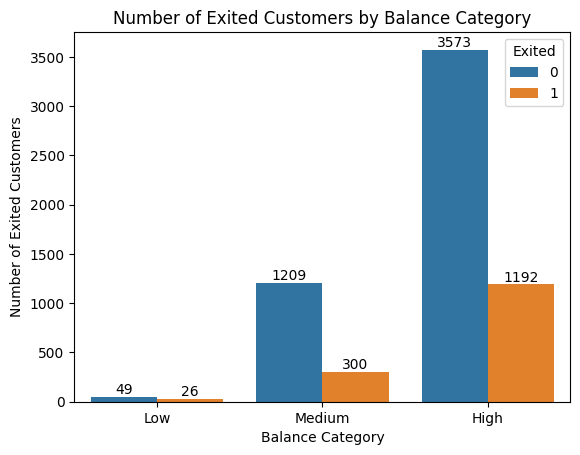

In [ ]:
ax = sns.countplot(data = df,x = 'Balance category',hue = "Exited")
for i in ax.containers:
  ax.bar_label(i)
plt.xlabel('Balance Category')
plt.ylabel('Number of Exited Customers')
plt.title('Number of Exited Customers by Balance Category')
plt.show

In [ ]:
#churn_rate by balance category ?
churn_rate_by_bal = df.groupby('Balance category')['Exited'].mean()*100
churn_rate_by_bal

,Exited
Balance category,
Low,34.666667
Medium,19.880716
High,25.015740


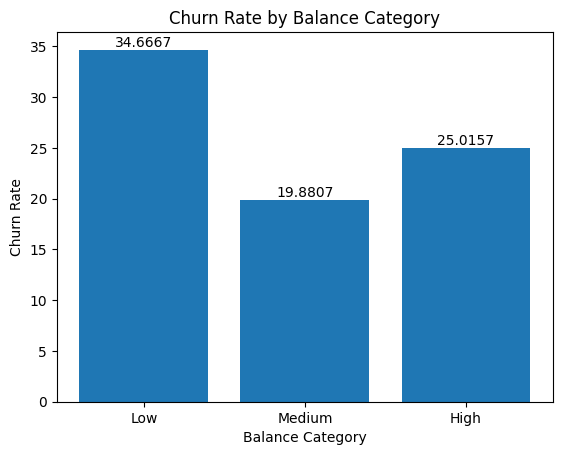

In [ ]:
ax = plt.bar(churn_rate_by_bal.index,churn_rate_by_bal.values)
plt.xlabel('Balance Category')
plt.bar_label(ax)
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Balance Category')
plt.show()

In [ ]:
#Are high-credit-score customers leaving?
churn_rate_by_creditscore =df.groupby('Credit_group')['Exited'].mean()*100
churn_rate_by_creditscore

,Exited
Credit_group,
Poor,21.689498
Fair,19.846327
Good,19.586984


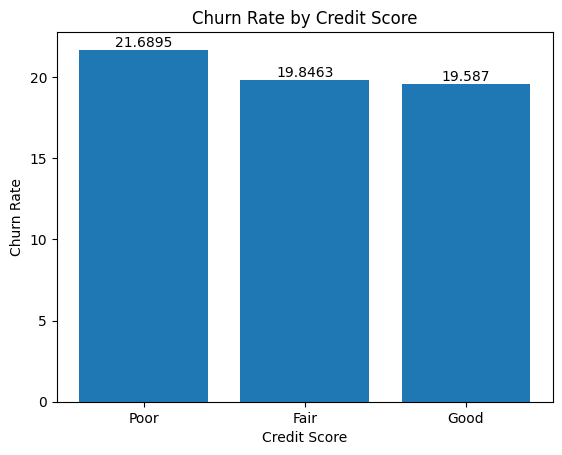

In [ ]:
ax = plt.bar(churn_rate_by_creditscore.index,churn_rate_by_creditscore.values)
plt.xlabel('Credit Score')
plt.bar_label(ax)
plt.ylabel('Churn Rate')
plt.title('Churn Rate by Credit Score')
plt.show()

In [ ]:
df[df['Exited']==1]['Credit_group'].value_counts()

,count
Credit_group,
Fair,1059
Poor,665
Good,313


In [ ]:
#Which customer profile is most valuable?
Customer_profile = df.groupby("Age_group")["Balance"].mean()
Customer_profile

,Balance
Age_group,
18-30,73131.262590
31-40,75583.362420
41-50,79122.193461
51-60,82401.663162
61-70,78774.506073
71-100,68197.016692


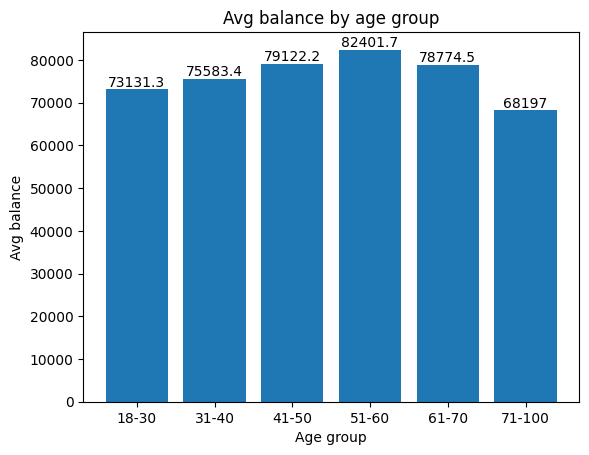

In [ ]:
ax = plt.bar(Customer_profile.index,Customer_profile.values)
plt.bar_label(ax)
plt.xlabel('Age group')
plt.ylabel('Avg balance')
plt.title('Avg balance by age group')
plt.show()

In [ ]:
df.head()

,Rownumber,Customerid,Surname,Creditscore,Geography,Gender,Age,Tenure,Balance,Numofproducts,Hascrcard,Isactivemember,Estimatedsalary,Exited,Balance category,Credit_group,Age_group
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1,NaN,Fair,41-50
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0,Medium,Fair,41-50
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1,High,Poor,41-50
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0,NaN,Fair,31-40
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0,High,Good,41-50


In [ ]:
#What percentage of total bank balance belongs to churned customers?
Churn_customer_bal = df[df['Exited']==1]['Balance'].sum()
total_balance = df['Balance'].sum()
Churn_customer_bal_pct = Churn_customer_bal/total_balance*100
Churn_customer_bal_pct

np.float64(24.26435730271586)

In [ ]:
# dataset download after analysis
df.to_csv('Bank churn clean.csv',index = False)